In [1]:
library(data.table)
library(uwot)
library(ggplot2)
library(tidyr)

Loading required package: Matrix


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack




In [4]:
# Get the number of cores allocated by SLURM
num_cores <- as.numeric(Sys.getenv("CORES"))
cat("Number of cores allocated by SLURM:", num_cores, "\n")


Number of cores allocated by SLURM: NA 


In [2]:
library(parallel)
num_cores <- detectCores()
cat("Total number of cores detected:", num_cores, "\n")


Total number of cores detected: 76 


In [5]:
library(parallel)
cpu_intensive_task <- function(x) {
  # Simulate some work
  Sys.sleep(0.5)
  sqrt(x) ^ 10
}
max_cores <- detectCores()  # Detect total available cores
cat("Detected Cores: ", max_cores, "\n")

for (num_cores in 1:max_cores) {
  cat("Testing with", num_cores, "cores...\n")
  start_time <- Sys.time()
  
  # Run the tasks in parallel
  results <- tryCatch({
    mclapply(1:(num_cores * 2), cpu_intensive_task, mc.cores = num_cores)
  }, error = function(e) {
    message("Error occurred: ", e$message)
    return(NULL)
  })
  
  end_time <- Sys.time()
  elapsed_time <- end_time - start_time
  
  cat("Elapsed time with", num_cores, "cores:", elapsed_time, "\n")
  
  if (is.null(results)) {
    cat("System started to fail with", num_cores, "cores.\n")
    break
  }
}


Detected Cores:  76 
Testing with 1 cores...
Elapsed time with 1 cores: 1.003124 
Testing with 2 cores...
Elapsed time with 2 cores: 1.010348 
Testing with 3 cores...
Elapsed time with 3 cores: 1.011118 
Testing with 4 cores...
Elapsed time with 4 cores: 1.0142 
Testing with 5 cores...
Elapsed time with 5 cores: 1.01681 
Testing with 6 cores...
Elapsed time with 6 cores: 1.02159 
Testing with 7 cores...
Elapsed time with 7 cores: 1.022148 
Testing with 8 cores...
Elapsed time with 8 cores: 1.025593 
Testing with 9 cores...
Elapsed time with 9 cores: 1.028956 
Testing with 10 cores...
Elapsed time with 10 cores: 1.029931 
Testing with 11 cores...
Elapsed time with 11 cores: 1.040995 
Testing with 12 cores...
Elapsed time with 12 cores: 1.036607 
Testing with 13 cores...
Elapsed time with 13 cores: 1.037307 
Testing with 14 cores...
Elapsed time with 14 cores: 1.041509 
Testing with 15 cores...
Elapsed time with 15 cores: 1.043721 
Testing with 16 cores...
Elapsed time with 16 cores: 1.0

In [7]:
library(parallel)
cpu_intensive_task <- function(x) {
  # Simulate some work
  Sys.sleep(0.5)
  sqrt(x) ^ 10
}
max_cores <- detectCores()  # Detect total available cores
cat("Detected Cores: ", max_cores, "\n")

for (num_cores in 1:max_cores) {
  cat("Testing with", num_cores, "cores...\n")
  start_time <- Sys.time()
  
  # Run the tasks in parallel
  results <- tryCatch({
    mclapply(1:(num_cores * 2), cpu_intensive_task, mc.cores = num_cores)
  }, error = function(e) {
    message("Error occurred: ", e$message)
    return(NULL)
  })
  
  end_time <- Sys.time()
  elapsed_time <- end_time - start_time
  
  cat("Elapsed time with", num_cores, "cores:", elapsed_time, "\n")
  
  if (is.null(results)) {
    cat("System started to fail with", num_cores, "cores.\n")
    break
  }
}


Detected Cores:  76 
Testing with 1 cores...
Elapsed time with 1 cores: 1.003171 
Testing with 2 cores...
Elapsed time with 2 cores: 1.008781 
Testing with 3 cores...
Elapsed time with 3 cores: 1.012871 
Testing with 4 cores...
Elapsed time with 4 cores: 1.015038 
Testing with 5 cores...
Elapsed time with 5 cores: 1.023909 
Testing with 6 cores...
Elapsed time with 6 cores: 1.021071 
Testing with 7 cores...
Elapsed time with 7 cores: 1.024506 
Testing with 8 cores...
Elapsed time with 8 cores: 1.047119 
Testing with 9 cores...
Elapsed time with 9 cores: 1.042198 
Testing with 10 cores...
Elapsed time with 10 cores: 1.048857 
Testing with 11 cores...
Elapsed time with 11 cores: 1.052888 
Testing with 12 cores...
Elapsed time with 12 cores: 1.054338 
Testing with 13 cores...
Elapsed time with 13 cores: 1.057865 
Testing with 14 cores...
Elapsed time with 14 cores: 1.055358 
Testing with 15 cores...
Elapsed time with 15 cores: 1.072901 
Testing with 16 cores...
Elapsed time with 16 cores:

In [2]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392"

In [4]:
info_split

total,used,free,shared,buff/cache,available
527267656,90407620,236729400,73060,200130636,433556608


In [3]:
rna = fread('/rds/project/rds-SDzz0CATGms/users/khms2/Mouse_atlas/analysis/MNC_LK_integrate/rna_pca_bart.csv')[-1,] %>% 
    setnames(c('cell', paste0('RNA_PC', 2:length(.)-1))) %>%
    as.data.frame() %>% tibble::column_to_rownames('cell')

adt = fread('/rds/project/rds-SDzz0CATGms/users/khms2/Mouse_atlas/analysis/MNC_LK_integrate/prot_pca_bart.csv')[-1,] %>% 
    setnames(c('cell', paste0('ADT_PC', 2:length(.)-1))) %>%
    as.data.frame() %>% tibble::column_to_rownames('cell')

In [4]:
summary(rownames(adt) == rownames(rna))

   Mode    TRUE 
logical  336409 

In [5]:
adt = adt[order(match(rownames(rna), rownames(adt))),]

In [6]:
summary(rownames(adt) == rownames(rna))

   Mode    TRUE 
logical  336409 

In [7]:
head(rna)
head(adt)

,RNA_PC1,RNA_PC2,RNA_PC3,RNA_PC4,RNA_PC5,RNA_PC6,RNA_PC7,RNA_PC8,RNA_PC9,RNA_PC10,⋯,RNA_PC21,RNA_PC22,RNA_PC23,RNA_PC24,RNA_PC25,RNA_PC26,RNA_PC27,RNA_PC28,RNA_PC29,RNA_PC30
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCTGAGACCTAGG-MNC_pool_1_1,5.457985,-2.965306500,-5.90951300,0.5821645,-4.0146440,-0.7718387,-0.6107739,3.4073427,1.572979,-1.1419598,⋯,-1.66653610,-1.5118712,-0.46907473,-1.4380705,1.8478897,-0.2871738,-1.29711320,-1.0737754,1.8656969,0.7418440
AAACCTGAGACGCTTT-MNC_pool_1_1,-4.888746,1.185435300,0.02559675,-0.9602824,0.7692732,0.3306284,-2.0248253,-0.4668507,2.815356,-0.1935216,⋯,-1.42575800,-0.8602100,-0.63678473,1.0705965,0.4176781,0.8235140,-1.09477000,-0.8346476,-0.2817187,-0.2851792
AAACCTGAGAGGACGG-MNC_pool_1_1,-5.354815,-0.009572052,-0.67561746,-1.4086632,1.7182282,2.3251405,-1.7588360,-0.3025606,2.865058,0.8175443,⋯,-0.63030106,-0.7093626,1.34979530,0.6882923,-0.3794244,0.3935349,0.17245962,-0.1921615,0.2387348,0.3944251
AAACCTGAGATAGGAG-MNC_pool_1_1,1.561819,-7.157252300,9.70722100,3.8988510,0.2040471,-0.3018248,-0.3122745,1.8245200,1.784285,-0.6214366,⋯,1.42386020,0.7339762,-0.35973045,-0.6635176,0.3474317,1.1230994,1.15164570,0.3442728,0.5851954,1.7544540
AAACCTGAGCGACGTA-MNC_pool_1_1,-5.239469,0.389955520,-1.77523220,0.3654825,1.6481172,1.4069653,-1.8415322,-0.2405006,2.154143,0.4312965,⋯,-0.04274749,-0.1222809,1.41839900,-0.4630581,0.6449419,-0.3912196,-0.57917950,-1.2474043,-0.4737589,-0.7375309
AAACCTGAGCGATGAC-MNC_pool_1_1,-4.580994,-0.212714060,-1.31671050,1.1083510,1.6951274,0.4685497,-1.9723245,-0.4487656,1.604988,0.6486040,⋯,0.69206180,-0.3243492,0.04282013,0.7735596,1.3252318,-0.1041982,0.05941834,-0.1753858,-0.3132340,-0.1677283


,ADT_PC1,ADT_PC2,ADT_PC3,ADT_PC4,ADT_PC5,ADT_PC6,ADT_PC7,ADT_PC8,ADT_PC9,ADT_PC10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCTGAGACCTAGG-MNC_pool_1_1,-1.8885455,4.5572590,-0.3742476,-1.16697260,0.50249930,3.8992946,0.9120321,-0.1403077,-0.6889890,-0.3975637
AAACCTGAGACGCTTT-MNC_pool_1_1,-0.7970214,-1.4043784,-0.6111605,0.79495270,0.81310600,-0.4762590,-0.2114615,-0.4521613,0.2083324,-0.4611833
AAACCTGAGAGGACGG-MNC_pool_1_1,-4.7247660,-1.8434093,-0.2787994,-0.02744711,0.03401116,-0.7661980,-0.1264697,-0.1649150,-0.3502949,-0.2961664
AAACCTGAGATAGGAG-MNC_pool_1_1,-1.0711703,-0.2760993,1.5968118,-1.33320500,-2.75309750,-0.5105910,-0.2647443,0.7037772,-0.5538166,-0.9060605
AAACCTGAGCGACGTA-MNC_pool_1_1,-0.6209960,-1.4611570,-0.4881731,0.50043464,0.45961082,-0.3137015,-0.1886088,0.4366448,0.3903527,-0.4132695
AAACCTGAGCGATGAC-MNC_pool_1_1,0.2140846,-0.9021255,-0.3653795,-0.86043435,0.90550150,-0.6501007,0.5701823,-0.3965715,0.4934589,-0.2751744


,ADT_PC1,ADT_PC2,ADT_PC3,ADT_PC4,ADT_PC5,ADT_PC6,ADT_PC7,ADT_PC8,ADT_PC9,ADT_PC10
RNA_PC1,-0.064050579,0.164409180,0.05210321,-0.01663403,-0.054837245,0.050959007,-0.0007334353,0.012354875,0.0359656210,-0.04328424
RNA_PC2,0.022607724,-0.045484084,-0.02366238,0.05550825,0.074394284,-0.007768832,0.0671070362,-0.015128652,0.0204401476,-0.03504369
RNA_PC3,0.080922961,-0.041880918,0.05151562,-0.06424289,-0.150314544,-0.029420036,-0.0720760533,0.037431529,0.0101853145,-0.03585033
RNA_PC4,-0.036699624,-0.003955908,0.07715532,-0.12550651,0.001811398,-0.057707286,0.0612293451,-0.023634633,0.0182859230,-0.01159574
RNA_PC5,0.012149324,0.014059216,0.08923138,0.06059435,0.030100422,-0.091168653,0.0230297712,-0.008543546,-0.0005420052,-0.03186648
RNA_PC6,-0.004000235,0.004881084,0.03008462,0.02180897,-0.014625839,-0.032869356,-0.0286114173,-0.039902283,-0.0408000685,0.05458903


ADT_PC1    ADT_PC2    ADT_PC3    ADT_PC4    ADT_PC5    ADT_PC6    ADT_PC7 
0.08092296 0.16440918 0.08923138 0.07898613 0.07439428 0.09943396 0.06710704 
   ADT_PC8    ADT_PC9   ADT_PC10 
0.10204680 0.09307685 0.05458903

[1] "ADT_PC1"  "ADT_PC2"  "ADT_PC3"  "ADT_PC4"  "ADT_PC5"  "ADT_PC6" 
 [7] "ADT_PC7"  "ADT_PC8"  "ADT_PC9"  "ADT_PC10"

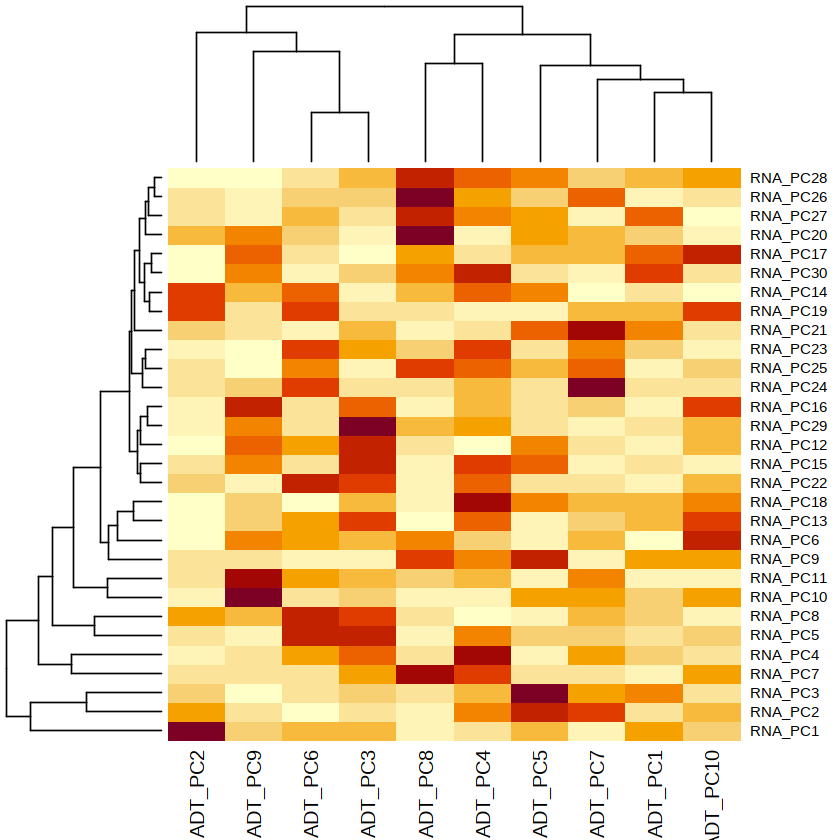

In [8]:
# Remove highly correlated PCs
cor = cor(rna, adt)
head(cor)
heatmap(abs(cor))
maxcor = apply(cor, 2, max)
maxcor
keep = colnames(cor[,maxcor<0.9])
keep

In [9]:
joint_dimred = cbind(rna, adt)
joint_dimred = apply(joint_dimred, 2, scale)

In [10]:
options(repr.plot.width=10, repr.plot.height=8)
K = 15
nn = 35
mindist = 0.3

In [11]:
joint_UMAP = umap(joint_dimred,
                n_neighbors = nn,
                min_dist = mindist)

In [12]:
joint_umap = as.data.table(joint_UMAP) %>% setnames(c('umap1', 'umap2')) %>%
    .[,cell:=rownames(rna)]

In [13]:
meta = fread('/rds/project/rds-SDzz0CATGms/users/khms2/Mouse_atlas/analysis/MNC_LK_integrate/obs_bart.csv')  %>% setnames('V1', 'cell') %>%
    merge(.,joint_umap, by='cell')


In [14]:
head(joint_umap)

umap1,umap2,cell
<dbl>,<dbl>,<chr>
10.3790908,-7.041431,AAACCTGAGACCTAGG-MNC_pool_1_1
-0.5292336,-5.139652,AAACCTGAGACGCTTT-MNC_pool_1_1
0.2678471,-2.495570,AAACCTGAGAGGACGG-MNC_pool_1_1
1.0617775,13.980129,AAACCTGAGATAGGAG-MNC_pool_1_1
-1.0278065,-4.565956,AAACCTGAGCGACGTA-MNC_pool_1_1
-1.2896045,-3.523265,AAACCTGAGCGATGAC-MNC_pool_1_1


In [15]:
summary(joint_umap$cell == rownames(rna))

   Mode    TRUE 
logical  336409 

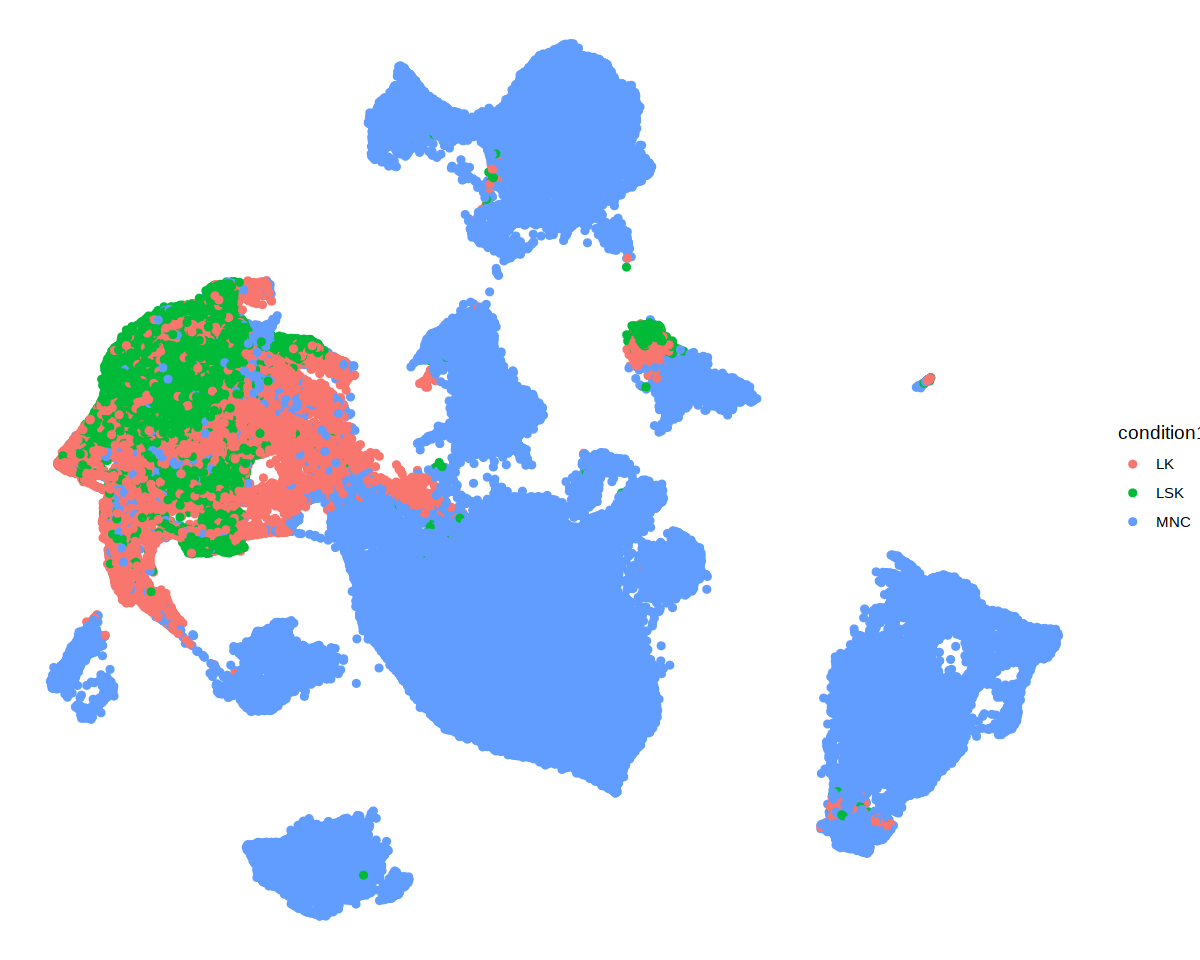

In [16]:
ggplot(meta, aes(umap1, umap2, col=condition1)) + geom_point() + theme_void()

In [17]:
stallion = c("1"="#D51F26","2"="#272E6A","3"="#208A42","4"="#89288F","5"="#F47D2B", "6"="#FEE500","7"="#8A9FD1","8"="#C06CAB","19"="#E6C2DC",
               "10"="#90D5E4", "11"="#89C75F","12"="#F37B7D","13"="#9983BD","14"="#D24B27","15"="#3BBCA8", "16"="#6E4B9E","17"="#0C727C", "18"="#7E1416","9"="#D8A767","20"="#3D3D3D")

In [18]:
celltype.colours = stallion[1:length(unique(meta$celltype))]
names(celltype.colours) = unique(meta$celltype)

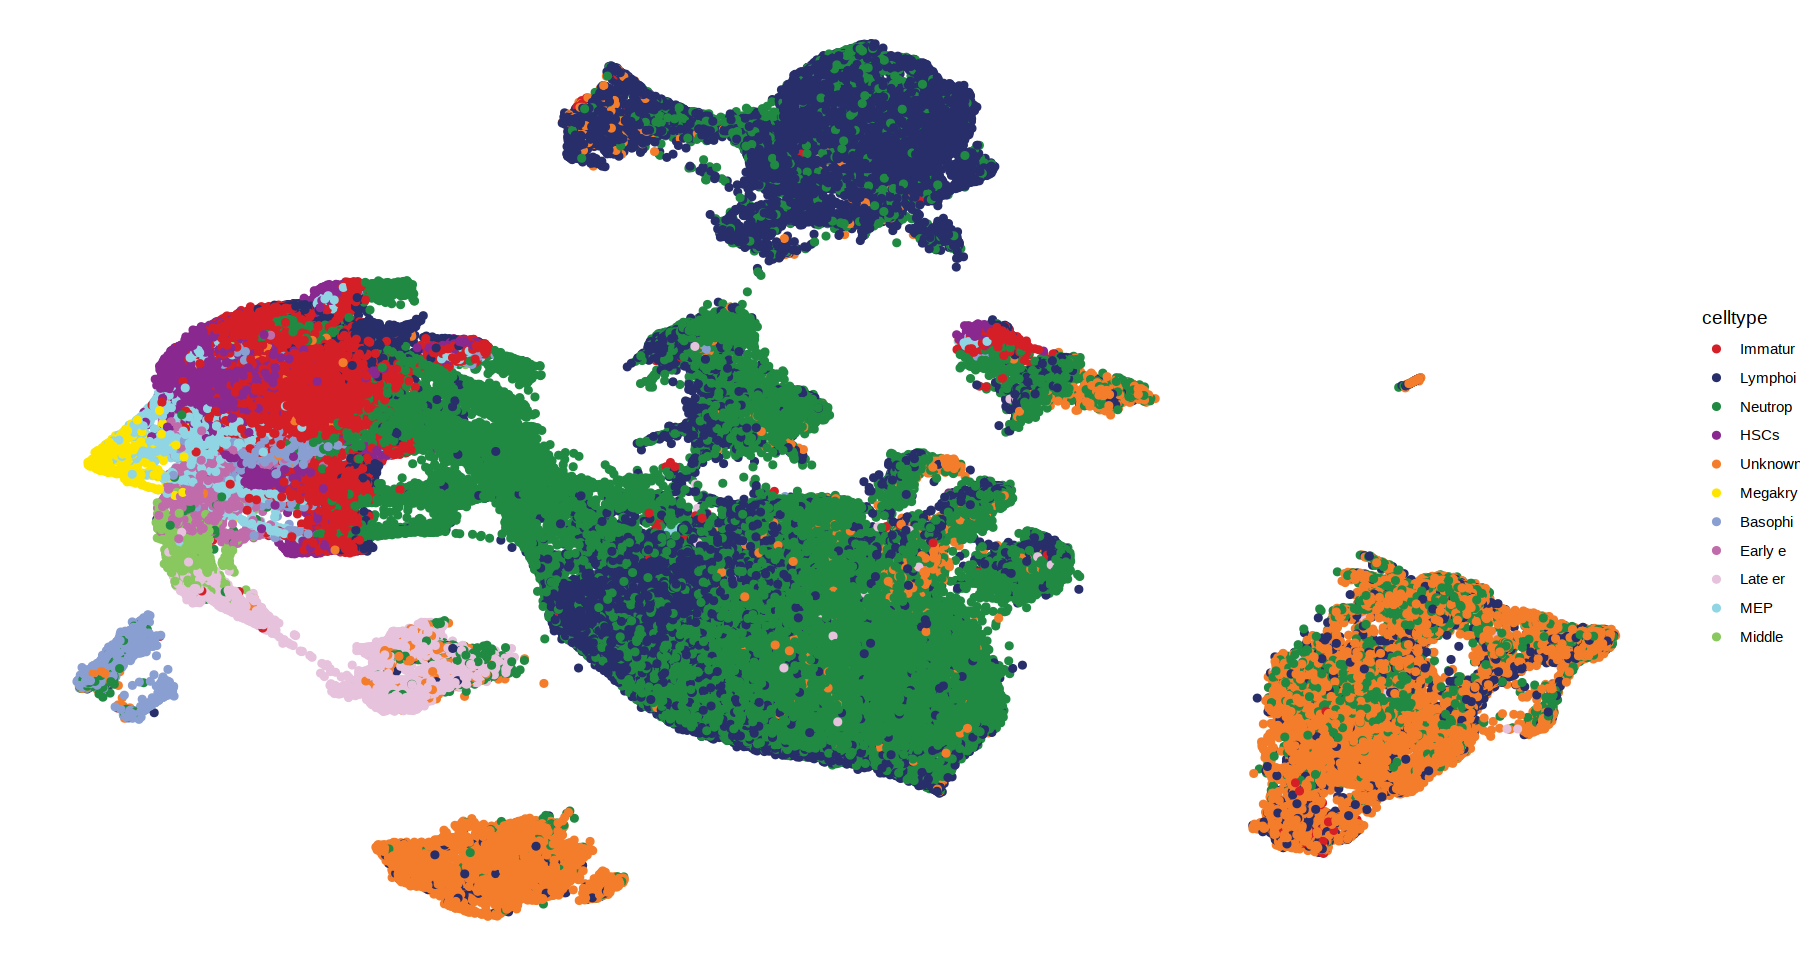

In [19]:
options(repr.plot.width=15, repr.plot.height=8)
ggplot(meta, aes(umap1, umap2, col=celltype)) + geom_point() + scale_colour_manual(values = celltype.colours) + theme_void()

In [20]:
summary(meta$cell == rownames(rna))

   Mode   FALSE 
logical  336409 

In [21]:
joint_dimred = as.data.table(joint_dimred) %>% .[,cell:=rownames(rna)]


In [22]:
meta = meta[,1:22]
meta = merge(meta, joint_dimred, by='cell')

In [23]:
head(meta)

cell,samplename,condition,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_scores,batch,xist_logn,⋯,ADT_PC1,ADT_PC2,ADT_PC3,ADT_PC4,ADT_PC5,ADT_PC6,ADT_PC7,ADT_PC8,ADT_PC9,ADT_PC10
<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
AAACCTGAGAAAGTGG-LSK_pool_2,LSK_pool_2,LSK,3186,10953,148,1.3506114,0.04266511,1,2.1510062,⋯,0.8079525,-0.3980217,-0.50668635,-0.10854247,1.1297280,-0.142455317,0.2593690,-0.3795317,-0.72875775,-0.009745510
AAACCTGAGAAAGTGG-MNC_pool_1_3,MNC_pool_1_3,,1371,6426,12,0.1867414,NA,0,0.0000000,⋯,-2.1073692,-0.9092539,-0.08890878,-0.05529811,-0.1869730,-0.597868849,-0.5328081,-0.2589576,-0.03233552,-0.048567099
AAACCTGAGAACAACT-MNC_pool_4_3,MNC_pool_4_3,,1041,2771,7,0.2526164,NA,0,0.0000000,⋯,-0.7840535,-0.6376898,-0.12856588,0.04365391,0.2860409,-0.431344207,0.3154318,-0.5972548,0.11990886,0.004792990
AAACCTGAGAAGATTC-MNC_pool_3_5,MNC_pool_3_5,,1362,5997,35,0.5836251,NA,0,0.0000000,⋯,0.2535384,-0.3363506,0.43946109,-1.57724686,-2.0805553,0.003371247,-0.1432633,0.7095337,0.31250928,0.640741253
AAACCTGAGAAGATTC-MNC_pool_3_6,MNC_pool_3_6,,1607,8563,27,0.3153101,NA,0,0.0000000,⋯,-0.1572399,0.1097927,2.02907349,-0.83160076,2.9476511,-1.542668632,1.5261162,2.9635772,0.64995476,-1.326642176
AAACCTGAGAAGGTGA-LK_pool_4,LK_pool_4,LK,2595,9489,108,1.1378002,0.02030238,1,0.9010716,⋯,0.8167252,0.6695782,4.10922618,3.44834266,-1.4290893,-0.382055656,1.7607880,0.2676794,-0.92690963,-0.005466889


In [24]:
library(parallel)

In [25]:
plot

function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x556776bc5de8>
<environment: namespace:base>

In [26]:

x = 'ADT_PC2'
    p = ggplot(meta, aes(umap1, umap2, col=meta[[x]])) + 
        geom_point() + 
        scale_colour_gradient2(low='blue', mid='grey90', high='red') +  
        theme_void()

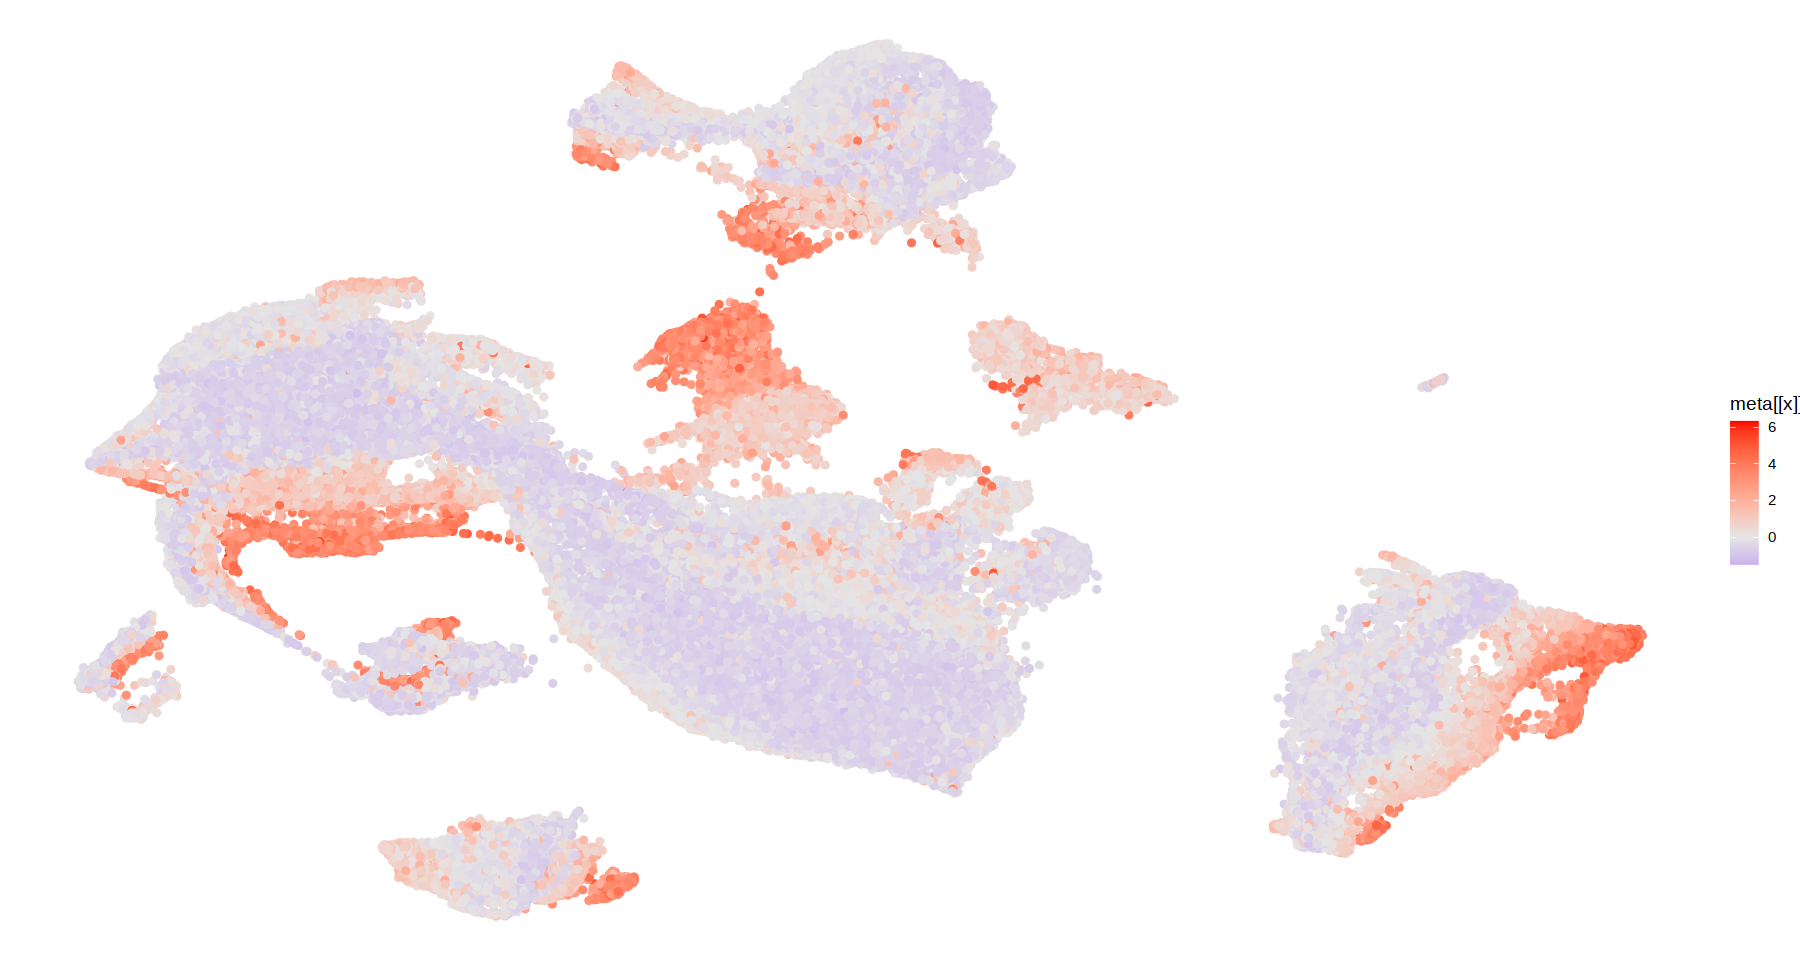

In [27]:
p

In [28]:
plot

function (x, y, ...) 
UseMethod("plot")
<bytecode: 0x556776bc5de8>
<environment: namespace:base>

In [29]:
plot = c(paste0('RNA_PC',1:5), paste0('ADT_PC', 1:5))
p = list()
plots = lapply(plot, function(x){
    p = ggplot(meta, aes(umap1, umap2, col=meta[[x]])) + 
        geom_point() + 
        scale_colour_gradient2(low='blue', mid='grey90', high='red', name = x) +  
        theme_void()
    return(p)
})

In [30]:
library(ggpubr)

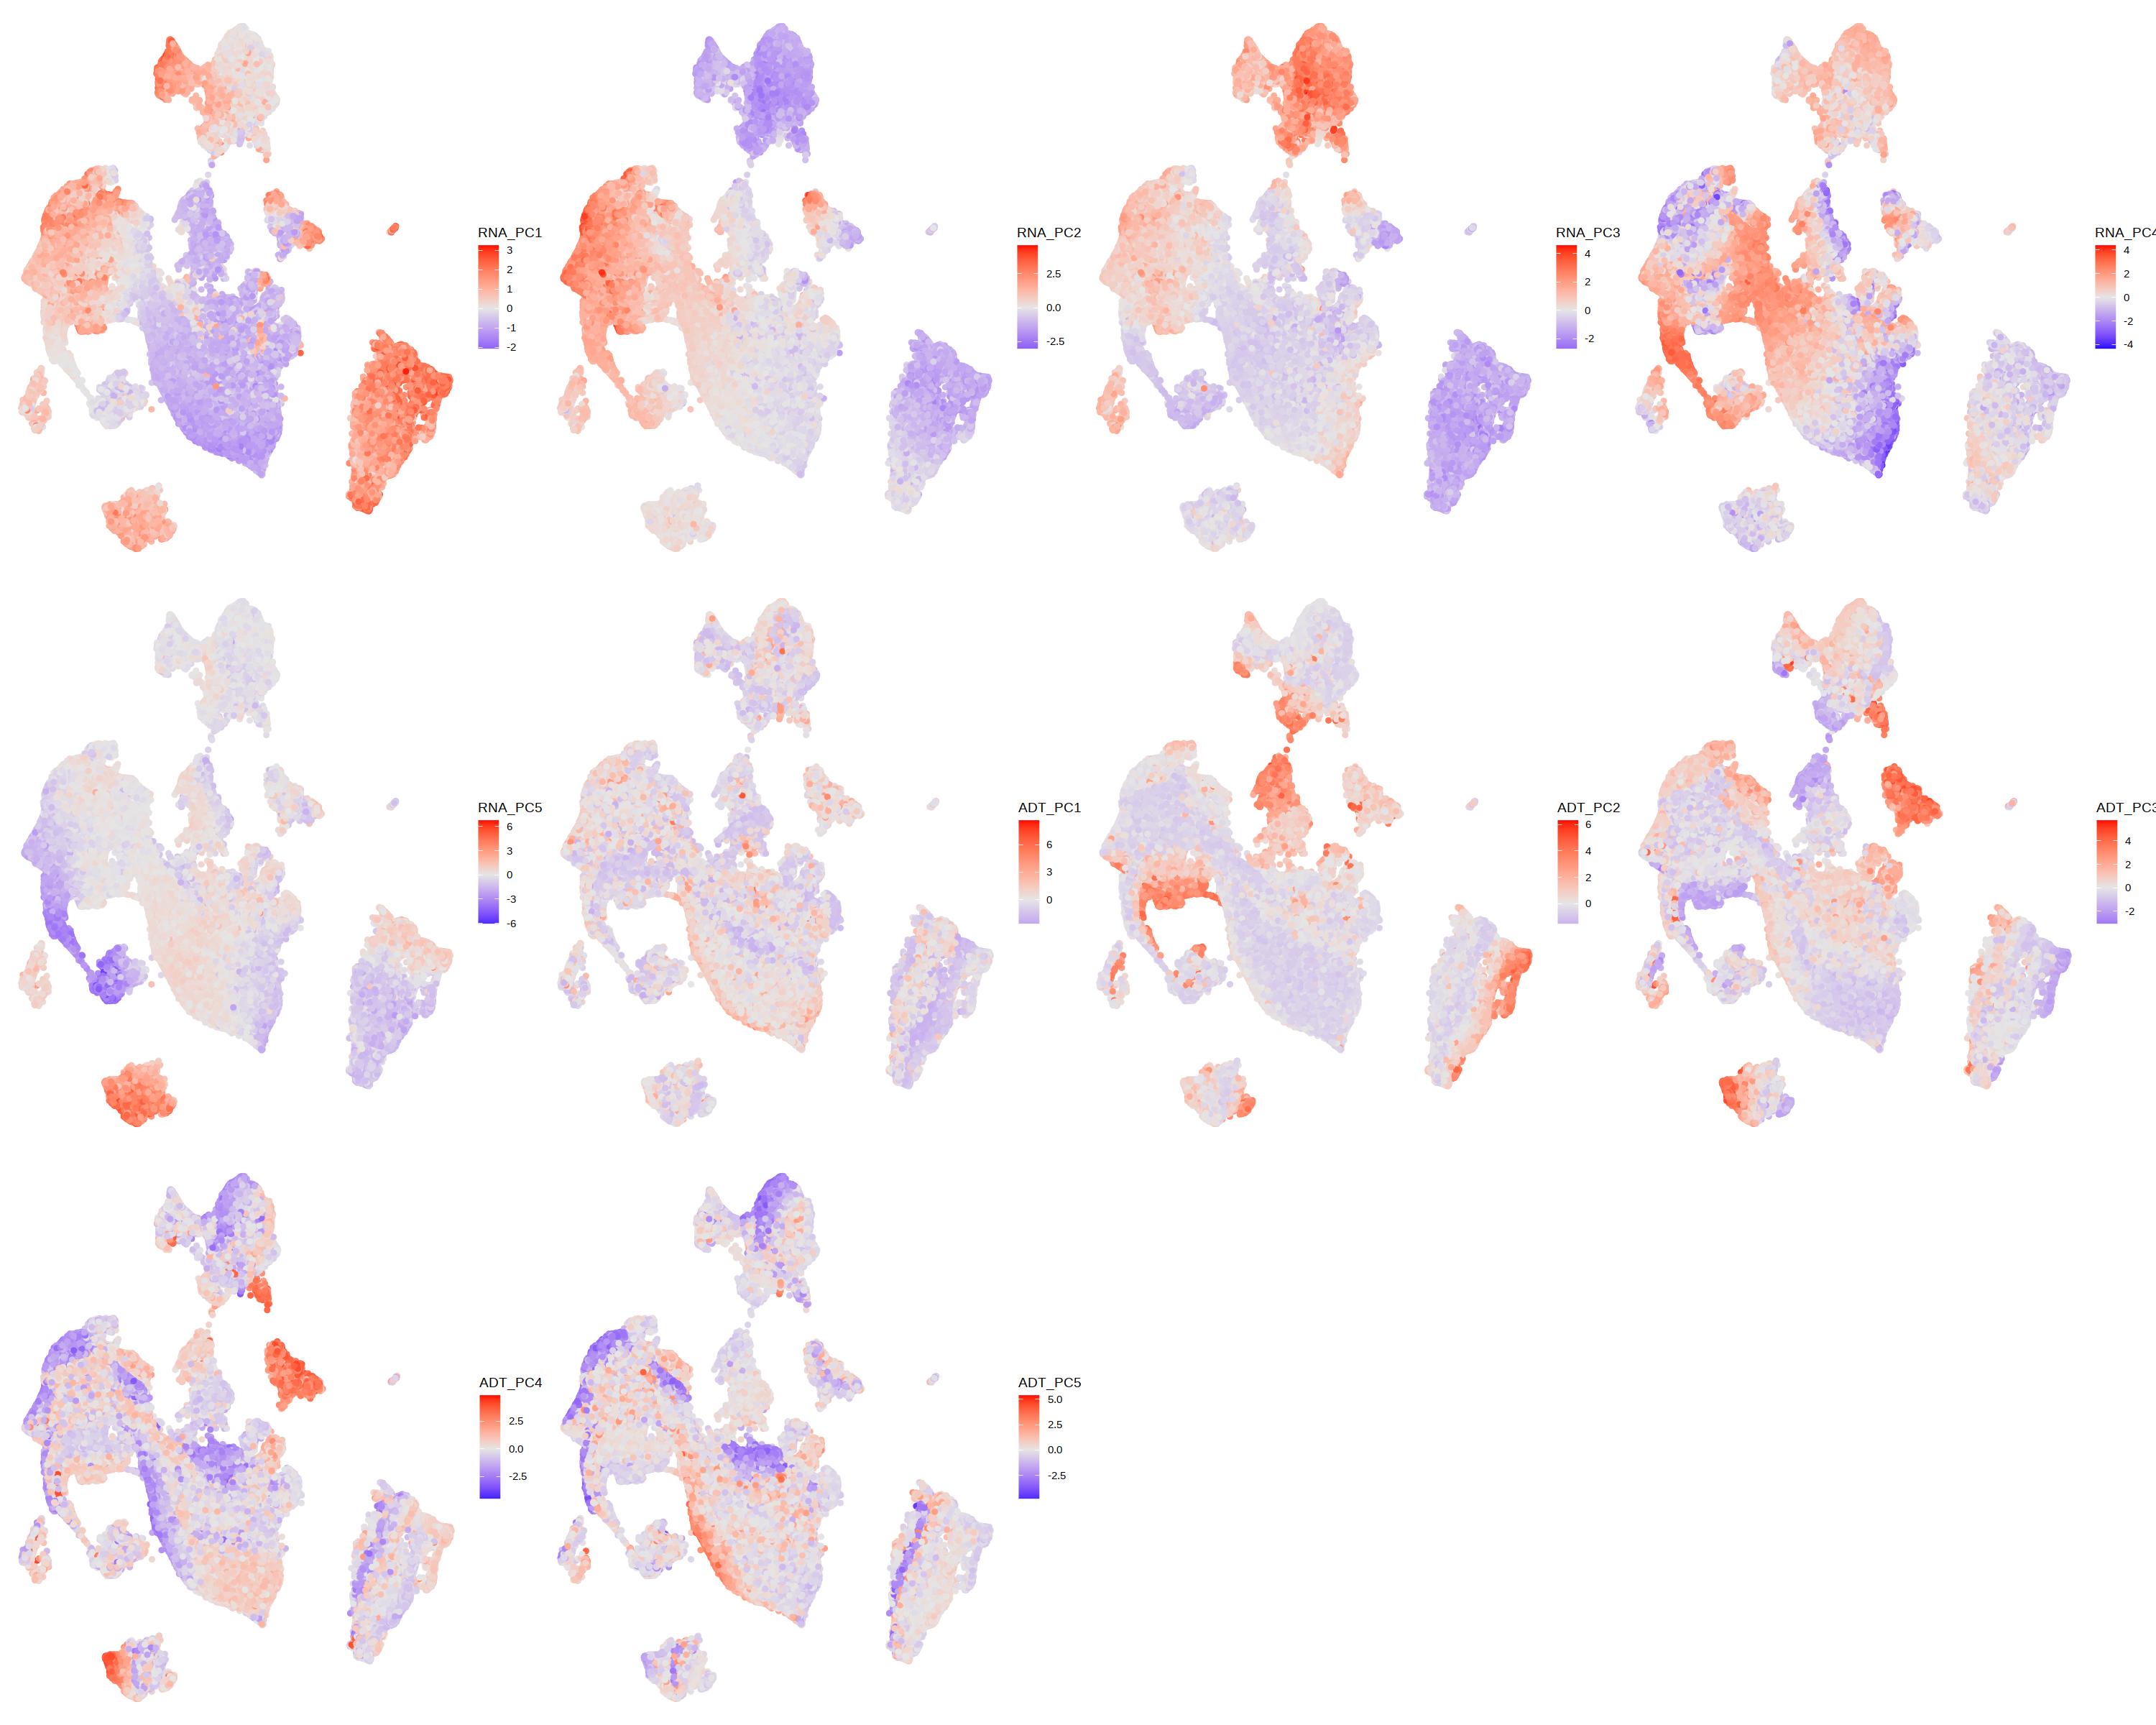

In [31]:
options(repr.plot.width=25, repr.plot.height=20)

ggarrange(plotlist =plots)

In [35]:
getwd()

[1] "/rds/project/rds-SDzz0CATGms/users/bt392"

In [36]:
fwrite(meta, '/rds/project/rds-SDzz0CATGms/users/bt392/dump/kats_umap.csv')